In [2]:
import numpy as np
import pymc as pm
import arviz as az
# -- use this line at the beginning of your notebook to turn on interactive plots
%matplotlib notebook
import scipy.io
# note these imports, thay may be useful in your own task
import statsmodels.api as sm

import matplotlib.pyplot as plt  # plotting library
import numpy as np  # work with numeric arrays without labeled axes
import xarray as xr  # work with arrays with labeled axes
import pandas as pd

In [3]:
x1 = 'HDB5.2.3.xlsx'
df_all = pd.read_excel(x1, header=None)

df_all = df_all[1:]  # 移除第一行
df_all.columns = df_all.iloc[0]  # 使用第一行作为列名
df_all = df_all[1:]  # 移除第一行
df_all.reset_index(drop=True, inplace=True)  # 重置行索引

df = df_all[df_all["TOK"] != "START"]
df = df.drop(df.columns[0], axis=1)

selected_columns = ['TAUTH', "IP","BT",'NEL', 'PLTH', 'RGEO','AMIN' ,'DELTA', 'KAPPAA', 'MEFF']
selected_columns2 = ['TAUTH', "IP","BT",'NEL', 'PLTH', 'RGEO','DELTA1','EPS', 'KAPPAA', 'MEFF','DB2P8','SELDB5','STDDB4V5']
selected_columns3 = ['TAUTH', "IP","BT",'NEL', 'PLTH', 'RGEO','DELTA1','EPS', 'KAPPAA', 'MEFF']

df[selected_columns] = df[selected_columns].apply(pd.to_numeric, errors='coerce')
df['EPS']=df['AMIN']/df['RGEO']
df['DELTA1']=df['DELTA']+1
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19
log_df=df.copy()
log_df[selected_columns3] = log_df[selected_columns3].apply(np.log)

DB2P8 = log_df[log_df['DB2P8'] == 1]
SELDB5 = log_df[log_df['SELDB5'] == 1]
STDDB4V5 = log_df[log_df['STDDB4V5'] == 1]
DB2P8 = DB2P8[selected_columns3]
SELDB5 = SELDB5[selected_columns3]
STDDB4V5 = STDDB4V5[selected_columns3]
DB2P8 = DB2P8.dropna()
SELDB5 = SELDB5.dropna()
STDDB4V5 = STDDB4V5.dropna()

In [7]:
DB2P8

1,TAUTH,IP,BT,NEL,PLTH,RGEO,DELTA1,EPS,KAPPAA,MEFF
5,-2.975930,-1.217734,0.790728,1.332102,0.625938,0.527093,0.0,-1.418447,-0.025224,0.405465
6,-3.015527,-1.220102,0.790728,1.317480,0.705076,0.521172,0.0,-1.409604,-0.028160,0.405465
11,-2.752786,-1.213686,0.790728,1.226712,0.123986,0.526502,0.0,-1.432100,-0.010810,0.405465
12,-2.660547,-1.217734,0.790728,1.328400,0.319181,0.526502,0.0,-1.417369,-0.025617,0.405465
13,-2.965979,-1.223495,0.790274,1.347294,0.709513,0.521766,0.0,-1.406800,-0.031479,0.405465
...,...,...,...,...,...,...,...,...,...,...
12499,-3.526761,-0.973390,0.098940,1.370165,0.506215,0.336472,0.0,-1.252763,0.000088,0.693147
12501,-3.528122,-1.037047,0.051643,1.484328,0.536493,0.336472,0.0,-1.203973,0.000039,0.693147
12503,-3.632121,-1.284821,0.049742,1.436987,0.366031,0.336472,0.0,-1.203973,0.000039,0.693147
12506,-3.537705,-1.369241,0.049742,1.301009,0.123986,0.336472,0.0,-1.203973,0.000039,0.693147


In [9]:
selected_columns4 = [ "IP","BT",'NEL', 'PLTH', 'RGEO','DELTA1','EPS', 'KAPPAA', 'MEFF']
X = DB2P8[selected_columns4]  # 自变量列
X['constant'] = 1
y=DB2P8["TAUTH"]
model = sm.OLS(y, X)
results = model.fit()

# 打印详细统计结果
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  TAUTH   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     5194.
Date:                Thu, 08 May 2025   Prob (F-statistic):               0.00
Time:                        12:12:12   Log-Likelihood:                 556.68
No. Observations:                1241   AIC:                            -1093.
Df Residuals:                    1231   BIC:                            -1042.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
IP             0.7577      0.025     30.314      0.0

Sequential sampling (4 chains in 1 job)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Output()

Output()

Output()

Sampling 4 chains for 500 tune and 5_000 draw iterations (2_000 + 20_000 draws total) took 908 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 16065 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


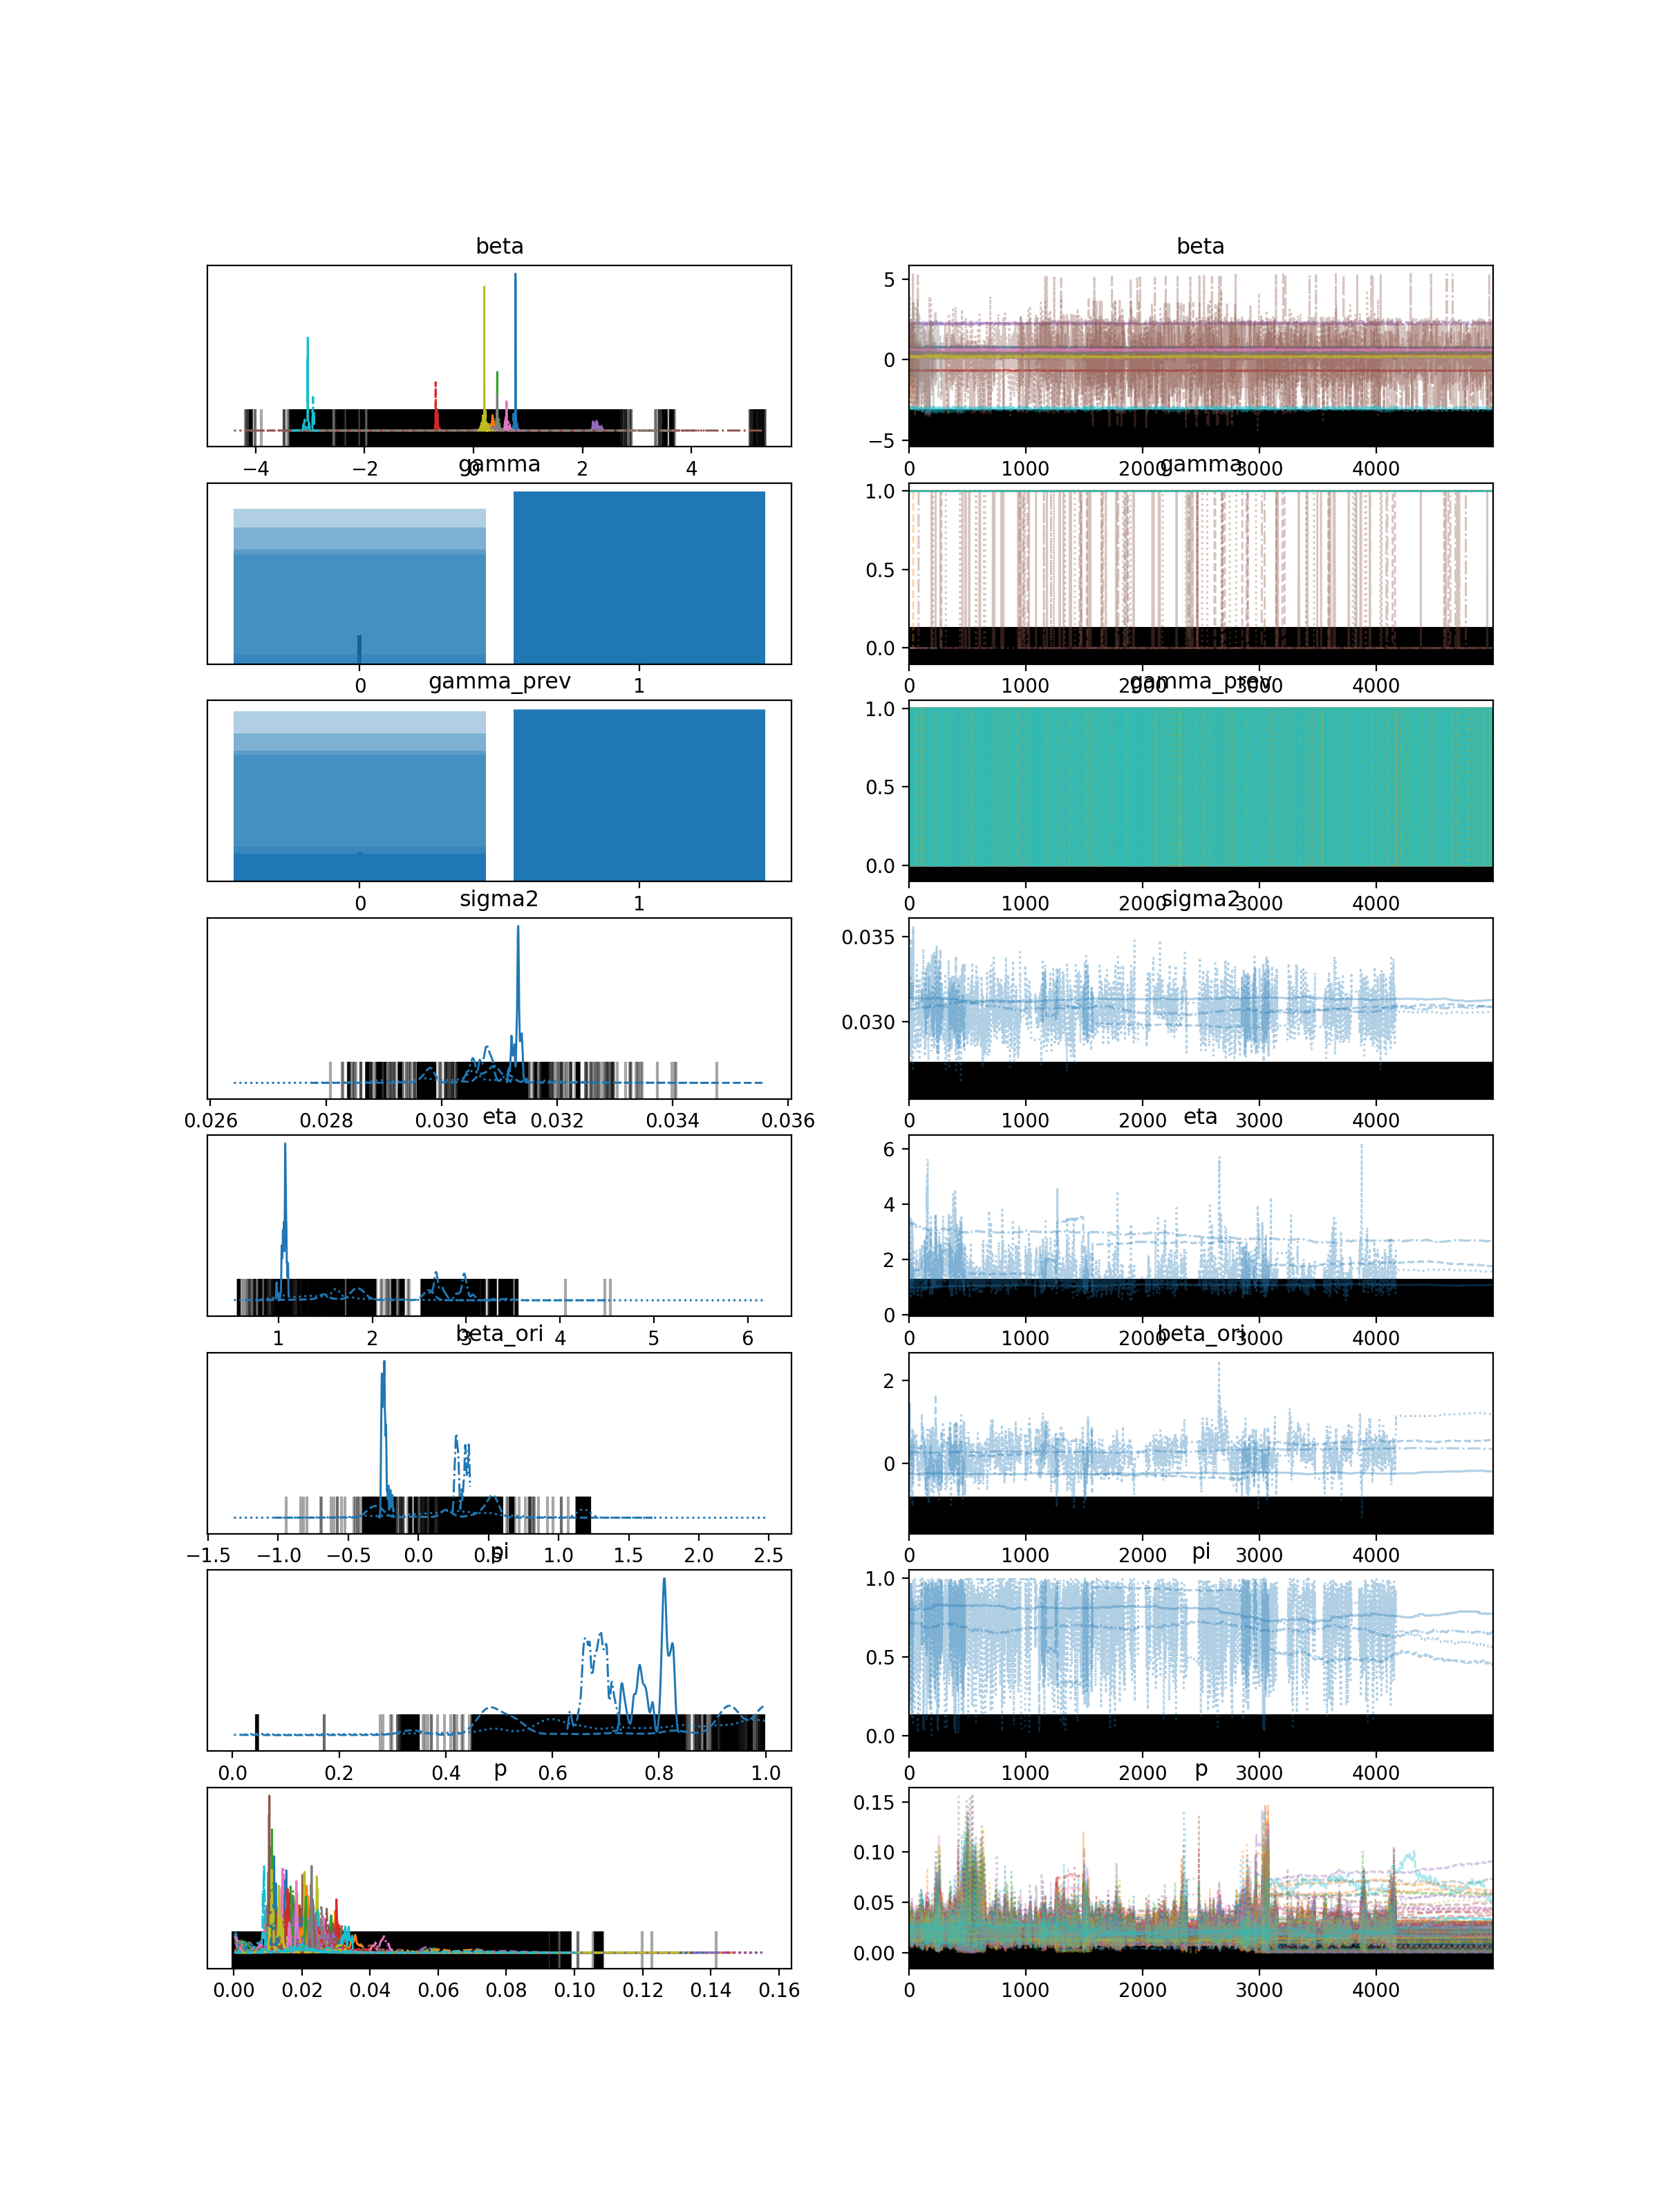

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  0.764  0.028   0.718    0.812      0.007    0.005      14.0   
beta[1]  0.347  0.065   0.291    0.413      0.008    0.006      25.0   
beta[2]  0.443  0.020   0.408    0.482      0.005    0.004      14.0   
beta[3] -0.678  0.015  -0.704   -0.649      0.003    0.003      21.0   
beta[4]  2.258  0.054   2.180    2.365      0.017    0.012      10.0   
...        ...    ...     ...      ...        ...      ...       ...   
p[45]    0.022  0.010   0.008    0.042      0.004    0.003       8.0   
p[46]    0.023  0.014   0.000    0.045      0.006    0.005       6.0   
p[47]    0.019  0.009   0.001    0.027      0.003    0.002       7.0   
p[48]    0.017  0.009   0.010    0.033      0.003    0.002      10.0   
p[49]    0.025  0.016   0.008    0.069      0.006    0.005      11.0   

         ess_tail  r_hat  
beta[0]      26.0   1.34  
beta[1]      20.0   1.11  
beta[2]     158.0   1.20  
beta[3]     150.0   1.13  


In [10]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 5000  # Number of samples
D = 10  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(50) * alpha, shape=50)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=5)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=50)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=4)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4, cores=1, step=pm.NUTS(target_accept=0.95))



# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

<IPython.core.display.Javascript object>


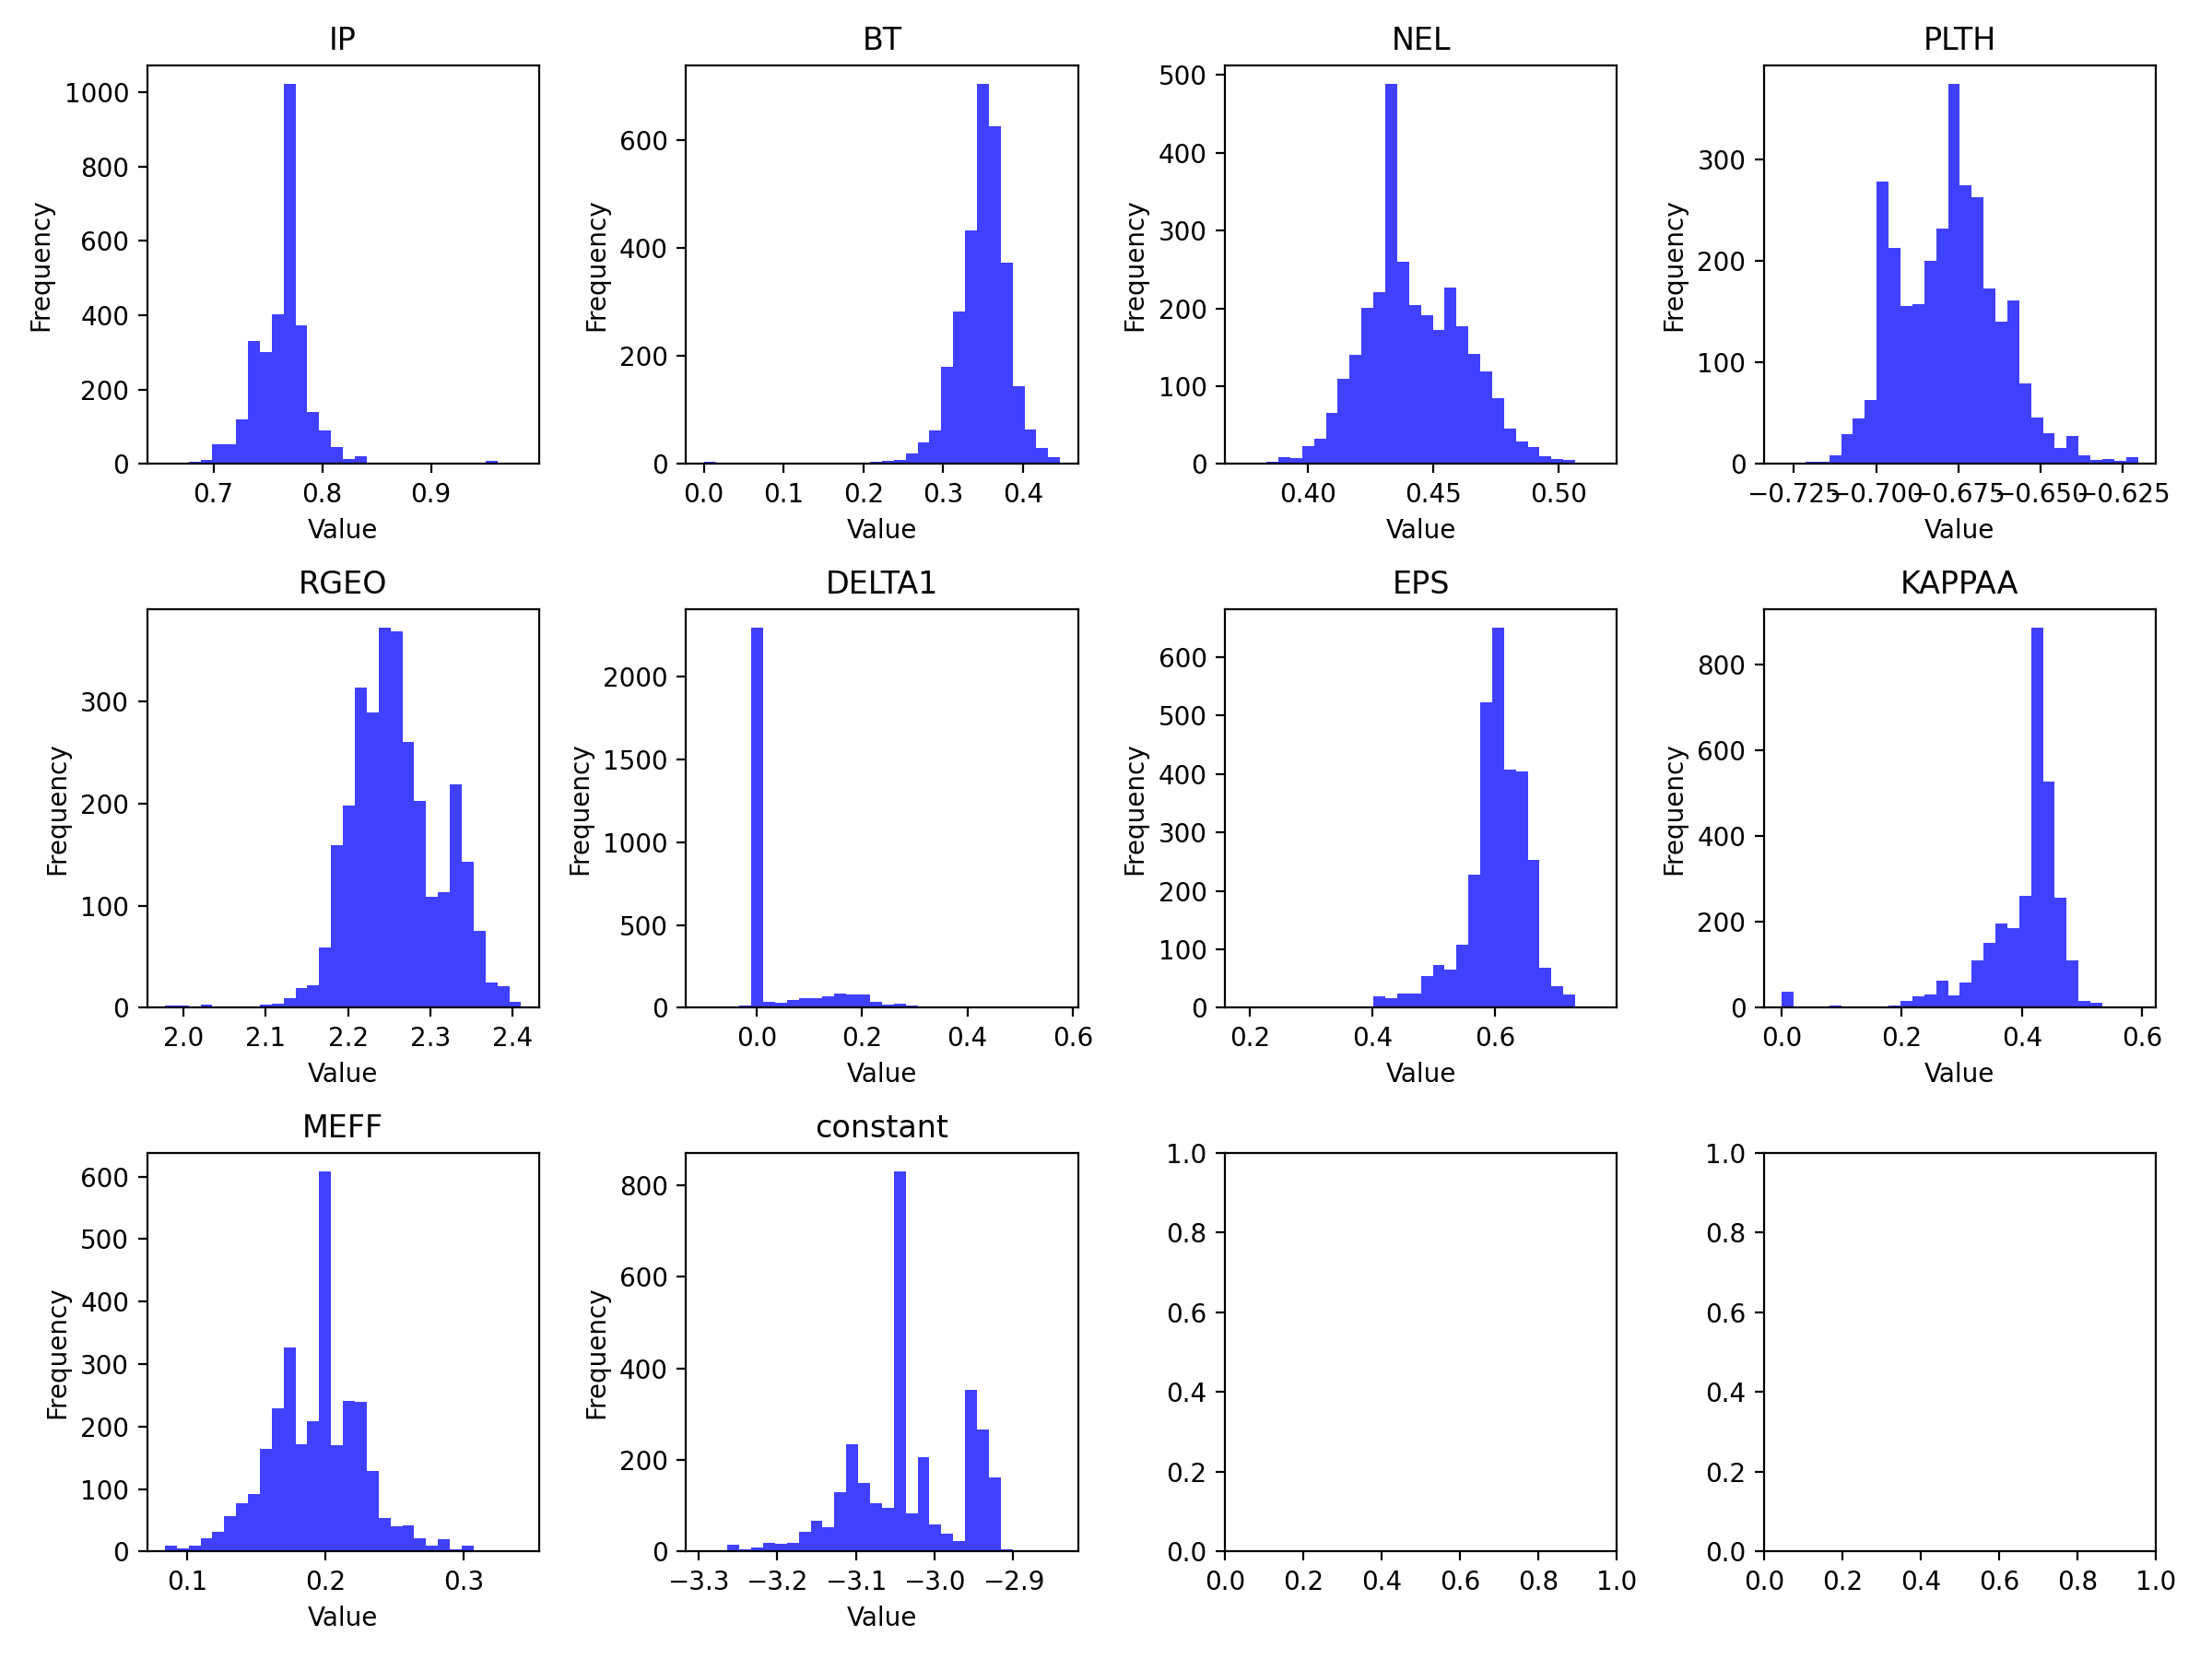

[1.         0.99833333 1.         1.         1.         0.23866667
 1.         0.98766667 1.         1.        ]
[ 0.76341039  0.34863526  0.44257921 -0.67774476  2.25837633  0.0377417
  0.60128224  0.40111022  0.19314224 -3.03468125]
[23.729      23.48266667 20.93266667 22.60733333 32.423      25.00166667
 24.43266667 22.83366667 28.182      11.66      ]
1000 samples' R² values=: 0.9743


In [11]:
# 从后验中随机抽取 10 个样本
num_samples = 3000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [12]:

trace.to_netcdf("scaling_law.nc")

# 查看并保存summary
summary_df = az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "beta_ori","eta", "pi", "p"])
print(summary_df)
summary_df.to_csv("scaling_law.csv")

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  0.764  0.028   0.718    0.812      0.007    0.005      14.0   
beta[1]  0.347  0.065   0.291    0.413      0.008    0.006      25.0   
beta[2]  0.443  0.020   0.408    0.482      0.005    0.004      14.0   
beta[3] -0.678  0.015  -0.704   -0.649      0.003    0.003      21.0   
beta[4]  2.258  0.054   2.180    2.365      0.017    0.012      10.0   
...        ...    ...     ...      ...        ...      ...       ...   
p[45]    0.022  0.010   0.008    0.042      0.004    0.003       8.0   
p[46]    0.023  0.014   0.000    0.045      0.006    0.005       6.0   
p[47]    0.019  0.009   0.001    0.027      0.003    0.002       7.0   
p[48]    0.017  0.009   0.010    0.033      0.003    0.002      10.0   
p[49]    0.025  0.016   0.008    0.069      0.006    0.005      11.0   

         ess_tail  r_hat  
beta[0]      26.0   1.34  
beta[1]      20.0   1.11  
beta[2]     158.0   1.20  
beta[3]     150.0   1.13  


Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [alpha, p, eta, beta_m, sigma2]
>CategoricalGibbsMetropolis: [S]


Output()

Output()

Sampling 2 chains for 500 tune and 3_000 draw iterations (1_000 + 6_000 draws total) took 81 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 5922 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


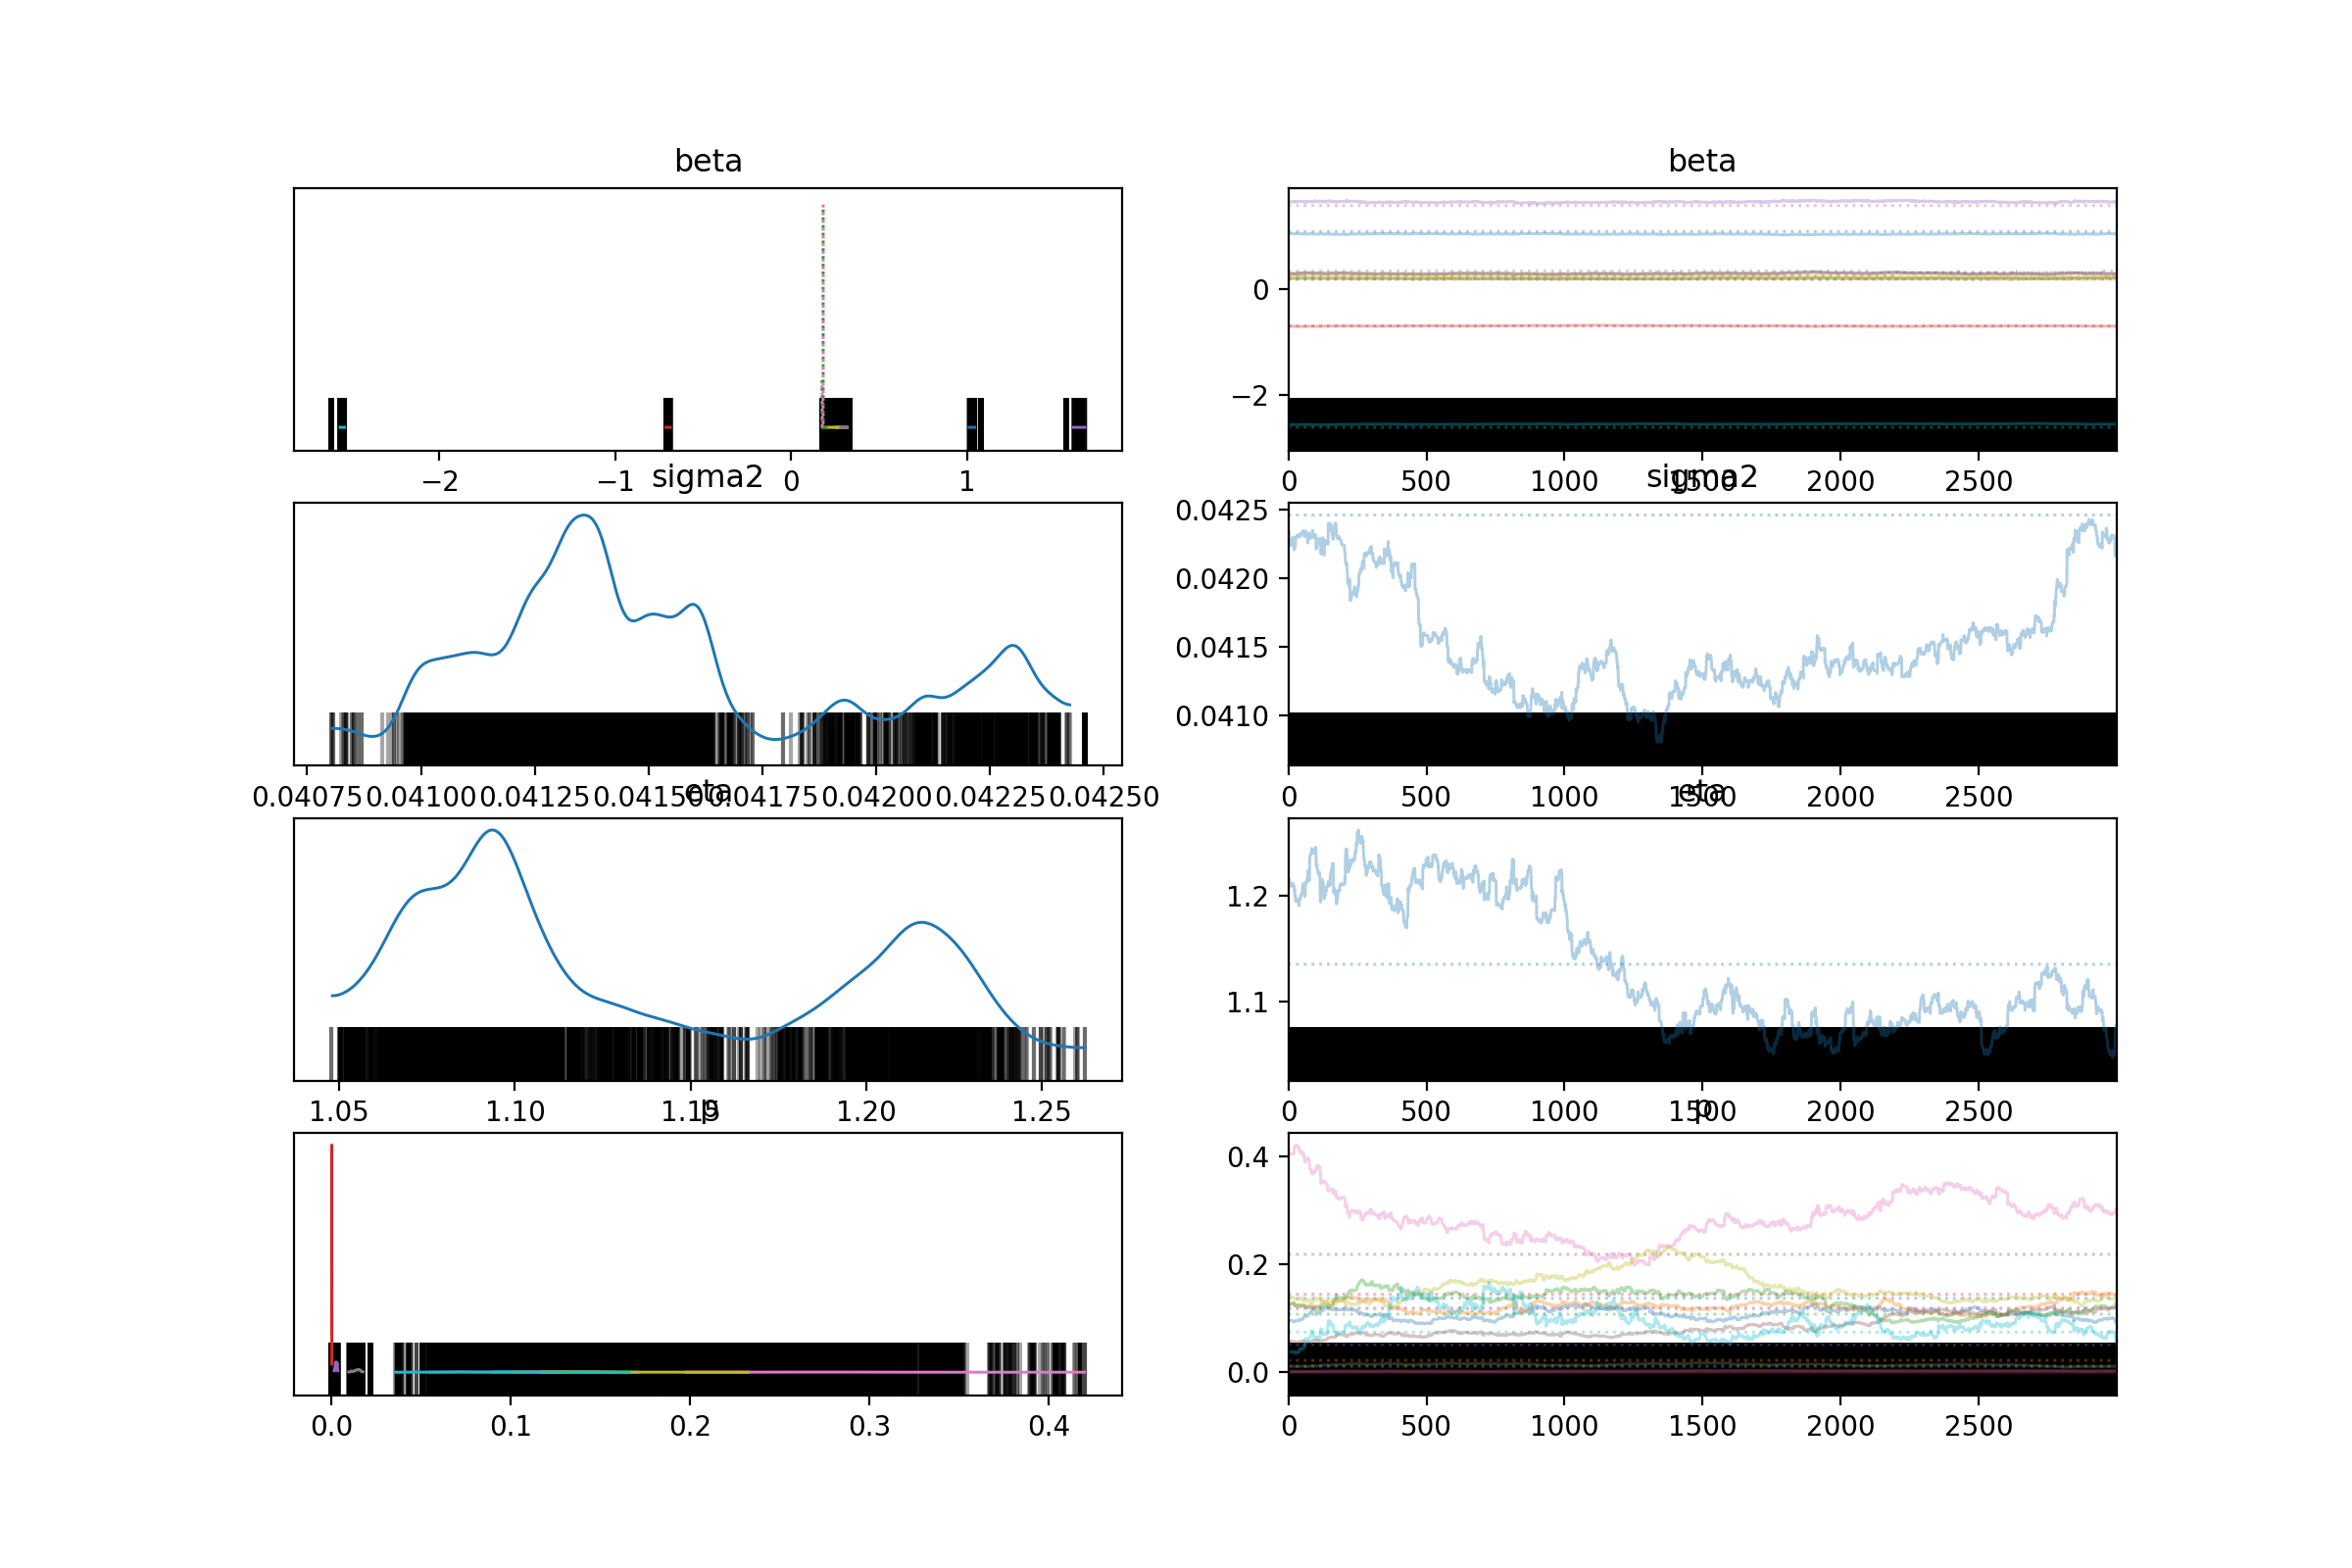

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  1.055  0.024   1.026    1.079      0.017    0.014       3.0   
beta[1]  0.187  0.009   0.177    0.199      0.006    0.005       2.0   
beta[2]  0.188  0.007   0.177    0.199      0.005    0.004       3.0   
beta[3] -0.701  0.004  -0.707   -0.692      0.001    0.001       7.0   
beta[4]  1.604  0.036   1.568    1.654      0.025    0.021       2.0   
beta[5]  0.275  0.023   0.248    0.305      0.012    0.009       5.0   
beta[6]  0.235  0.053   0.177    0.299      0.037    0.032       3.0   
beta[7]  0.307  0.022   0.278    0.334      0.014    0.012       3.0   
beta[8]  0.243  0.008   0.224    0.252      0.005    0.004       3.0   
beta[9] -2.581  0.031  -2.612   -2.545      0.022    0.019       2.0   
sigma2   0.042  0.001   0.041    0.042      0.000    0.000       3.0   
eta      1.135  0.043   1.065    1.230      0.024    0.019       3.0   
p[0]     0.123  0.015   0.097    0.137      0.010    0.008      

In [106]:

# Step 1: Generate simulated data
np.random.seed(0)
N = 3000  # Number of samples
D = 10  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=1.0)  # Dirichlet prior concentration parameter
    p = pm.Dirichlet("p", a=pm.math.ones(10) * alpha, shape=10)  # Class probabilities

    S = pm.Categorical("S", p=p, shape=D)  # Class assignment for predictors (0-9)

    eta = pm.InverseGamma("eta", alpha=1.0, beta=1.0)  # Variance for beta_m
    beta_m = pm.Normal("beta_m", mu=0.0, sigma=eta, shape=10)  # Regression coefficients for each class

    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S



    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=0.1, beta=0.1)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X, beta )  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, return_inferencedata=True, cores=1)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta",  "sigma2", "eta",  "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "sigma2", "eta", "p"])
print(summary)

<IPython.core.display.Javascript object>


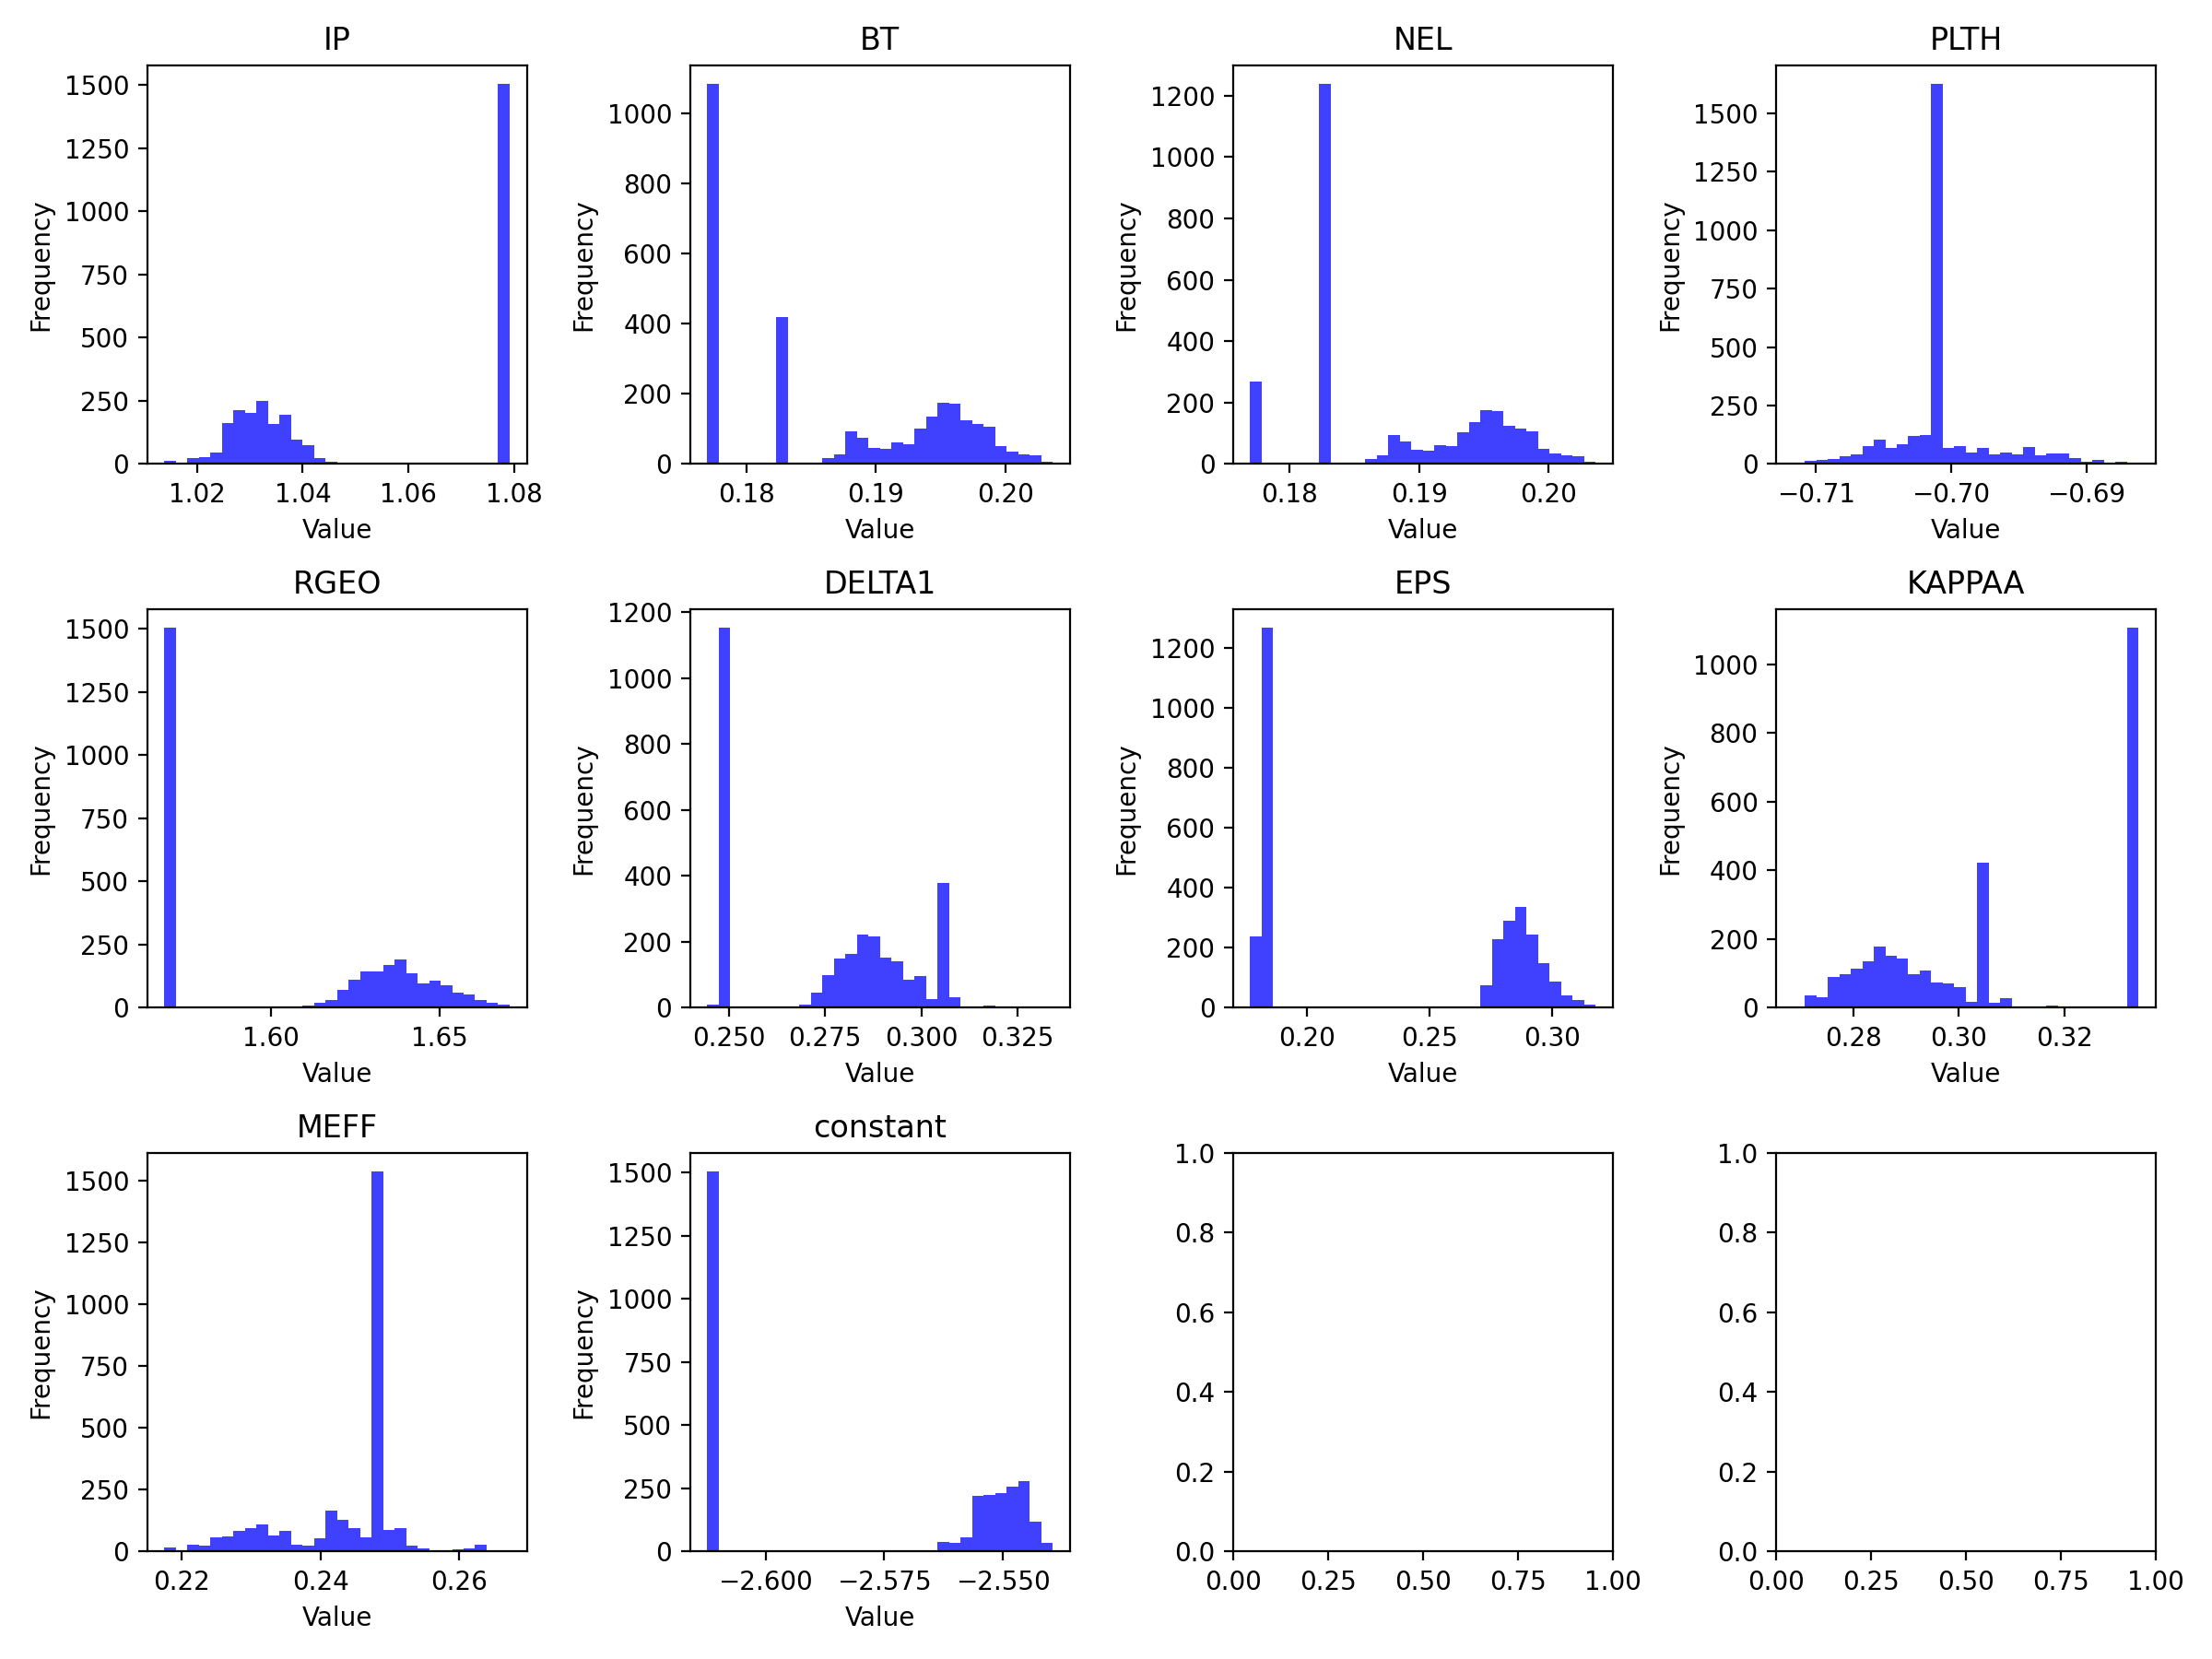

[ 1.0555299   0.18664245  0.18829426 -0.70055803  1.60326163  0.27435272
  0.23479058  0.30716803  0.24346224 -2.58134617]
[7.496      3.35333333 3.081      6.504      3.504      1.97566667
 0.079      2.40333333 2.00266667 4.992     ]
1000 samples' R² values=: 0.9538


In [108]:
# 从后验中随机抽取 10 个样本
num_samples = 3000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []

for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X @ (beta_sample )  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X.shape[0])  # 从预测分布采样
    S_new.append(beta_sample)
    beta_new_look.append(S_sample)
    
    predictions.append(y_pred)
S_new1 = np.array(S_new)

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)


predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [136]:
summary = az.summary(trace, var_names=["beta"])
print(summary[["r_hat"]])

         r_hat
beta[0]   2.12
beta[1]   1.97
beta[2]   1.98
beta[3]   1.41
beta[4]   2.06
beta[5]   1.93
beta[6]   2.29
beta[7]   2.67
beta[8]   1.51
beta[9]   2.26
